In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [3]:
# Generate random data

np.random.seed(2)

pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000) / pageSpeeds

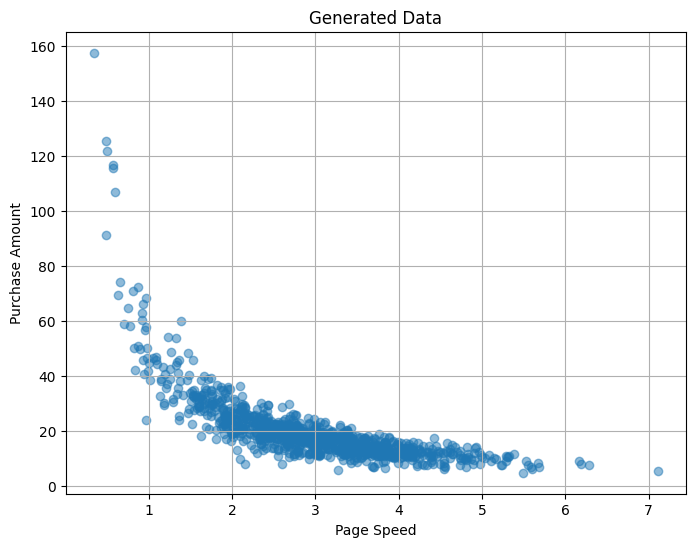

In [4]:
# Scatter Plot

plt.figure(figsize=(8,6))
plt.scatter(pageSpeeds, purchaseAmount, alpha=0.5)
plt.xlabel("Page Speed")
plt.ylabel("Purchase Amount")
plt.title("Generated Data")
plt.grid(True)
plt.show()

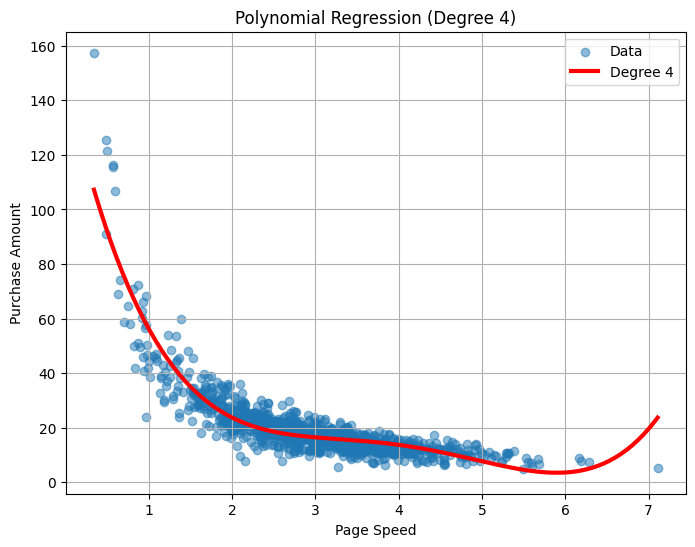

In [5]:
# Degree 4 Polynomial

x = np.array(pageSpeeds)
y = np.array(purchaseAmount)

p4 = np.poly1d(np.polyfit(x, y, 4))

xp = np.linspace(x.min(), x.max(), 200)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.5, label="Data")
plt.plot(xp, p4(xp), color='red', linewidth=3, label="Degree 4")
plt.xlabel("Page Speed")
plt.ylabel("Purchase Amount")
plt.title("Polynomial Regression (Degree 4)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Evaluate Degree 4
r2 = r2_score(y, p4(x))

print("Degree 4 R² =", r2)


Degree 4 R² = 0.8293766396303073


In [7]:
# Compare Different Degrees

degrees = [2,3,4,5,6,7]

print("\nModel Comparison")
print("-"*30)

best_degree = None
best_r2 = -999

for degree in degrees:

    model = np.poly1d(np.polyfit(x, y, degree))
    prediction = model(x)
    score = r2_score(y, prediction)

    print(f"Degree {degree}: R² = {score:.4f}")

    if score > best_r2:
        best_r2 = score
        best_degree = degree

print("\nBest Polynomial Degree:", best_degree)
print("Best R²:", best_r2)



Model Comparison
------------------------------
Degree 2: R² = 0.6927
Degree 3: R² = 0.7842
Degree 4: R² = 0.8294
Degree 5: R² = 0.8554
Degree 6: R² = 0.8701
Degree 7: R² = 0.8778

Best Polynomial Degree: 7
Best R²: 0.8778369781712095


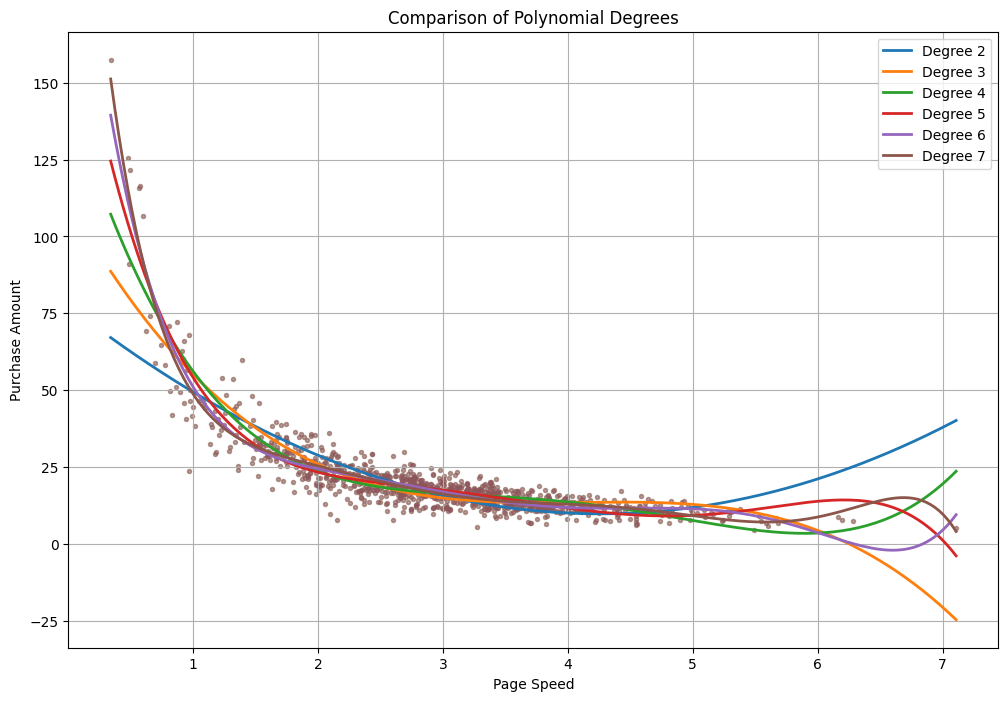

In [8]:
# Visualise All Polynomial Fits

plt.figure(figsize=(12,8))

for degree in degrees:

    model = np.poly1d(np.polyfit(x, y, degree))

    plt.scatter(x, y,
                s=8,
                alpha=0.15)

    plt.plot(xp,
             model(xp),
             linewidth=2,
             label=f"Degree {degree}")

plt.xlabel("Page Speed")
plt.ylabel("Purchase Amount")
plt.title("Comparison of Polynomial Degrees")
plt.legend()
plt.grid(True)
plt.show()

## Questions:
What is the R² score for the 4th-degree polynomial?

Which polynomial degree gives the highest R²?

Does a higher-degree polynomial always produce a better model?

Which degree would you choose and why?

Which polynomial appears to overfit the data?
